## **the parabolic mirror**
#### the parabolic mirror has a focal length of $f= $ 3mm. the general form of a parabola is $f(x)=\frac{1}{4 f}$, which means its equation is given by $y(x)=\frac{x^2}{12}$. its width is 69.282 mm, and its height is 100 mm. 

## **the OAP (off axis parabolic mirror)**
#### we're given the parent focal length (38.1 mm) and the radius of curature (76.2 mm). we must determine which section of the parabola this corresponds to. the offset angle is $90 \deg$.

#### examining the dimensions, (height and width are both 76.2 mm), we determine the points of intersection are at $x=76.2-38.1=38.1$ mm and $x=76.2+38.1=114.3$ mm.


### **establish what's needed to plot reflected rays.** 
#### let $\vec{h}$ be the incident ray coming from the ion, and $\hat{n}$ is the unit normal vector to the point of tangency. the reflected ray $\vec{r}$ is given by:
### $\vec{r}=\vec{h}-2\ (\vec{h} \cdot \hat{n})\hat{n} $

## **find the normal vector.** 

#### the equation of the line tangent to the point $(x_0, f(x_0))$, or $(x_0, y_0)$, where the ray hits the mirror has slope $m_t=f'(x_0)$. its form is $y_{tan}(x)=m\cdot (x-x_0)+y_0$. the slope of normal vector is $m_n=$ -1/(slope of tangent vector), the negative reciprocal. the equation of the normal line is then $y_{n}(x)=-\frac{1}{m_t}\cdot (x-x_0)+y_0$. in our case, $dy/dx=x/6$. then at point $x_0$, $m_n=-dx/dy=-6/x_0$. so $\vec{n}=(-x_0, 6).$

## **find the vector of incident ray, ($\vec{h}$)**.
#### we can determine the vector for the incident ray by calculating the slope of that line. the slope is given by $m_{line}=dy/dx=(\text{y-coord of ion}-\text{y-coord of tangent point})/(\text{x-coord of ion}-\text{x-coord of tangent point})$. the vector is $(dx, dy).$

## **parameterize the reflected ray.** 

#### to plot the reflected ray, take the result from $\vec{r}=(r_x, r_y)$, we have the x and y components.  from this we can write a parametric equation for the reflected ray. the general form for a parametric equation is $p(t)=a+tb$, where $a$ is a point on the curve and $b$ is the direction vector, and $t$ is a variable. so given $r_x$ and $r_y$ from above, we can write parametric equations for the reflected ray. here $(x_0, f(x_0))$ is the tangent point on the parabola.

## **determine points  of intersection between reflected rays and the OAP.**

#### we use scipy's fsolve (which finds the roots of a function) to find the points of intersection between the rays that are reflected off the parabola and onto the OAP.

## **reflect the rays off the oap.**

#### using the process detailed above, we will again find the normal vector to determine $\vec{r}$. 

#### the expanded expression of the OAP is $\frac{-x^2+2hx-h^2}{2\cdot 76.2} +v $. its derivative is $ \frac{h-x}{76.2}$, and $-dx/dy=76.2/(x-h)$. then, $\vec{n}=(x_0-h, 76.2)$. let $(x_1, f(x_1))$ be the coordinate of where the reflected ray hits the OAP. we parameterize the rays reflected off the OAP again:
#### $x=x_1+r_x\cdot (\text{length})$ and
#### $y=f(x_1)+r_y\cdot(\text{length})$

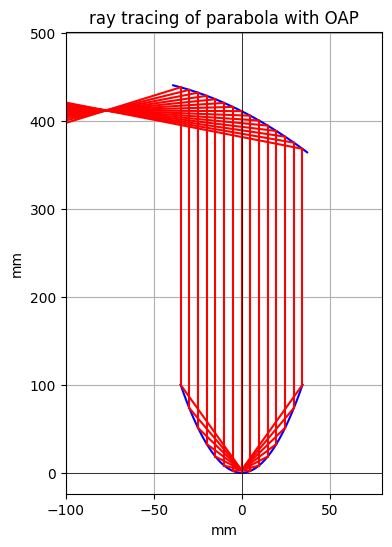

In [53]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve


#function of parabola with focal length of 3mm
def parabola(x):
        return x**2/12
    
#define horizontal and vertical controls for OAP in mm
h=-77
v=450

#function of the OAP
def oap(x): 
    return -(x-h)**2/(2*76.2)+v 

#parent focal length of OAP : 38.1 mm
#coordinate for focus for OAP
xfocus2=h
yfocus2=v-38.1 

#ion position offset
x_offset=0 #set x-offset for ion position
y_offset=0 # set y-offset for ion position

#ion position and offset from focal length of 3mm or (0,3)
ion_x=0+x_offset
ion_y=3+y_offset

#define parameters for parabolic mirror: width in mm
width = 69.282  #mm

#control desired number of rays 
number_of_rays = 15 

#define ray space 
x_rays = np.linspace(-width/2, width/2, number_of_rays) 


# --- OAP coefficients general form: y = ax^2 + bx + c ---
a, b, c = -.00656168, .0131234*h, -.00656168*h**2 + v 

#plot the parabola
x_parabola = np.linspace(-width/2, width/2, 100)
y_parabola = parabola(x_parabola)
plt.figure(figsize=(8, 6))
plt.plot(x_parabola, y_parabola, label='Parabola ', color='blue')

#plot the OAP
x_oap = np.linspace(38.1+h,114.3+h,400) 
y_oap = oap(x_oap)
plt.plot(x_oap, y_oap, label="OAP", color='blue')

#generate a bunch of rays originating from ion position 
for xx in x_rays:
    #rays originate from (ion_x, ion_y) 
    xi = xx
    yi = parabola(xi)
    x_incident=[ion_x, xi] 
    y_incident=[ion_y, yi]

    #plot incident rays
    plt.plot(x_incident, y_incident, 'r')

    #find the normal at points of intersection
    normal = np.array([-xi, 6]) # normal vector for the parabolic mirror 
    normal = normal / np.linalg.norm(normal) #normalize the vector 

    #define the vector of incident rays 
    incident = np.array([xi-ion_x, yi-ion_y])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted = np.dot(incident, normal) #take the dot product of the normal vector and the incident ray
    reflected = incident - 2 * dotted * normal
    reflected = reflected / np.linalg.norm(reflected)

    # --- define parametric line: x = x0 + t*dx, y = y0 + t*dy ---
    x0, y0 = xi-reflected[0]*xi, yi-reflected[1]*yi
    dx, dy = reflected[0], reflected[1]

    # --- define equation to solve: y(t) - oap(x(t)) = 0 ---
    def intersection_function(t):
        x = x0 + t * dx
        y = y0 + t * dy
        return y - (a * x**2 + b * x + c)
    
    # --- use fsolve to find root (intersection t) ---
    initial_guess = 0.5  # A reasonable guess
    t_solution = fsolve(intersection_function, initial_guess)[0]
    
    # ensure sure it's a valid (non-negative) intersection
    if t_solution < 0:
        exit()
    
    # compute intersection point
    x_int = x0 + t_solution * dx
    y_int = y0 + t_solution * dy

    # line segment from start to intersection
    t_vals = np.linspace(0, t_solution-yi, 100)
    x_line = x0 + (t_vals+xi) * dx
    y_line = y0 + (t_vals+yi) * dy

    #plot the rays reflected off the parabola and onto the OAP
    plt.plot(x_line, y_line, color='red')

    def x_surface(t):
        return x0 + (t+xi) * dx

        
    def y_surface(t):
        return y0 + (t+yi) * dy
        
    xf=x_surface(t_solution-yi)
    yf=y_surface(t_solution-yi)
    
    x00=x_surface(0)
    y00=y_surface(0)
            

    #find reflected rays off the OAP
    #find the normal at points of intersection
    normal2 = np.array([xf-h, 76.2]) # normal vector for the OAP
    normal2 = normal2 / np.linalg.norm(normal2) #normalize the vector 

    #define the vector of rays that hit OAP surface
    surface=np.array([xf-x00, yf-y00])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted2 = np.dot(surface, normal2) #take the dot product of the normal vector and the incident ray
    reflected2 = surface - 2 * dotted2 * normal2
    reflected2 = reflected2 / np.linalg.norm(reflected2)

    #reflected ray
    length = 300
    xff = x_surface(t_solution-yi) + reflected2[0] * (length)
    yff = y_surface(t_solution-yi) + reflected2[1] * (length)

    #plot rays reflected off the OAP
    plt.plot([xf, xff], [yf, yff], 'r')

plt.xlabel('mm')
plt.ylabel('mm')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.title('ray tracing of parabola with OAP')  
ax = plt.gca() # Get the current Axes object
ax.set_aspect(.5) # Set aspect ratio 
ax.set_xlim(-100, 80);

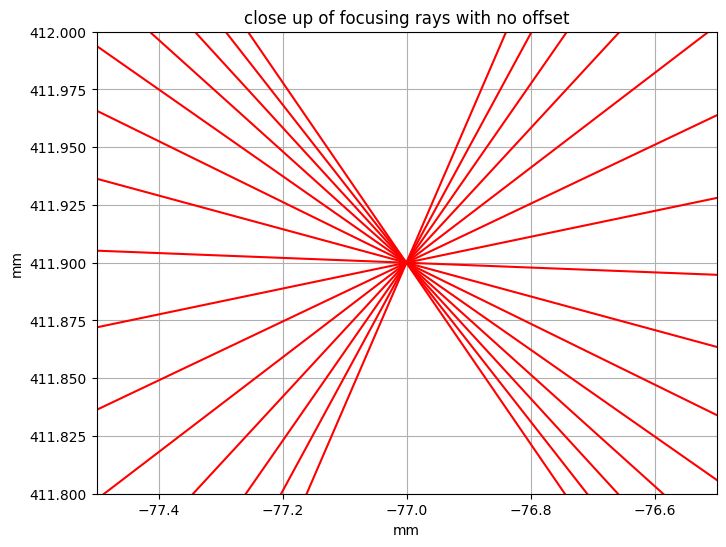

In [54]:
#zoom in to see how rays focus when there's no offset:

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve


#function of parabola with focal length of 3mm
def parabola(x):
        return x**2/12
    
#define horizontal and vertical controls for OAP in mm
h=-77
v=450

#function of the OAP
def oap(x): 
    return -(x-h)**2/(2*76.2)+v 

#parent focal length of OAP : 38.1 mm
#coordinate for focus for OAP
xfocus2=h
yfocus2=v-38.1 

#ion position offset
x_offset=0 #set x-offset for ion position
y_offset=0 # set y-offset for ion position

#ion position and offset from focal length of 3mm or (0,3)
ion_x=0+x_offset
ion_y=3+y_offset

#define parameters for parabolic mirror: width in mm
width = 69.282  #mm

#control desired number of rays 
number_of_rays = 15 

#define ray space 
x_rays = np.linspace(-width/2, width/2, number_of_rays) 


# --- OAP coefficients general form: y = ax^2 + bx + c ---
a, b, c = -.00656168, .0131234*h, -.00656168*h**2 + v 

#plot the parabola
x_parabola = np.linspace(-width/2, width/2, 100)
y_parabola = parabola(x_parabola)
plt.figure(figsize=(8, 6))
plt.plot(x_parabola, y_parabola, label='Parabola ', color='blue')

#plot the OAP
x_oap = np.linspace(38.1+h,114.3+h,400) 
y_oap = oap(x_oap)
plt.plot(x_oap, y_oap, label="OAP", color='blue')

#generate a bunch of rays originating from ion position 
for xx in x_rays:
    #rays originate from (ion_x, ion_y) 
    xi = xx
    yi = parabola(xi)
    x_incident=[ion_x, xi] 
    y_incident=[ion_y, yi] 

    #plot incident rays
    plt.plot(x_incident, y_incident, 'r')

    #find the normal at points of intersection
    normal = np.array([-xi, 6]) # normal vector for the parabolic mirror 
    normal = normal / np.linalg.norm(normal) #normalize the vector 

    #define the vector of incident rays 
    incident = np.array([xi-ion_x, yi-ion_y])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted = np.dot(incident, normal) #take the dot product of the normal vector and the incident ray
    reflected = incident - 2 * dotted * normal
    reflected = reflected / np.linalg.norm(reflected)

    # --- define parametric line: x = x0 + t*dx, y = y0 + t*dy ---
    x0, y0 = xi-reflected[0]*xi, yi-reflected[1]*yi
    dx, dy = reflected[0], reflected[1]

    # --- define equation to solve: y(t) - oap(x(t)) = 0 ---
    def intersection_function(t):
        x = x0 + t * dx
        y = y0 + t * dy
        return y - (a * x**2 + b * x + c)
    
    # --- use fsolve to find root (intersection t) ---
    initial_guess = 0.5  # A reasonable guess
    t_solution = fsolve(intersection_function, initial_guess)[0]
    
    # ensure sure it's a valid (non-negative) intersection
    if t_solution < 0:
        exit()
    
    # compute intersection point
    x_int = x0 + t_solution * dx
    y_int = y0 + t_solution * dy

    # line segment from start to intersection
    t_vals = np.linspace(0, t_solution-yi, 100)
    x_line = x0 + (t_vals+xi) * dx
    y_line = y0 + (t_vals+yi) * dy

    #plot the rays reflected off the parabola and onto the OAP
    plt.plot(x_line, y_line, color='red')

    def x_surface(t):
        return x0 + (t+xi) * dx

        
    def y_surface(t):
        return y0 + (t+yi) * dy
        
    xf=x_surface(t_solution-yi)
    yf=y_surface(t_solution-yi)
    
    x00=x_surface(0)
    y00=y_surface(0)
            

    #find reflected rays off the OAP
    #find the normal at points of intersection
    normal2 = np.array([xf-h, 76.2]) # normal vector for the OAP
    normal2 = normal2 / np.linalg.norm(normal2) #normalize the vector 

    #define the vector of rays that hit OAP surface
    surface=np.array([xf-x00, yf-y00])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted2 = np.dot(surface, normal2) #take the dot product of the normal vector and the incident ray
    reflected2 = surface - 2 * dotted2 * normal2
    reflected2 = reflected2 / np.linalg.norm(reflected2)

    #reflected ray
    length = 300
    xff = x_surface(t_solution-yi) + reflected2[0] * (length)
    yff = y_surface(t_solution-yi) + reflected2[1] * (length)

    #plot rays reflected off the OAP
    plt.plot([xf, xff], [yf, yff], 'r')


plt.xlabel('mm')
plt.ylabel('mm')
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.title('close up of focusing rays with no offset')  
ax = plt.gca() # Get the current Axes object
#ax.set_aspect(.5) # Set aspect ratio 
ax.set_xlim(-77.5, -76.5) # zoom in to see where rays focus
ax.set_ylim(411.8, 412); # zoom in to see where rays focus
#ax.set_xlim(-100, 100);

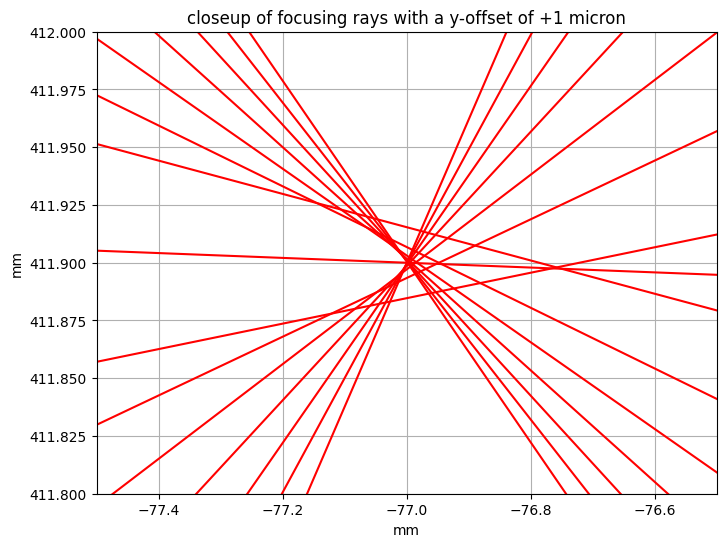

In [55]:
#if there's an offset, we can zoom in to see the effect.


import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve


#function of parabola with focal length of 3mm
def parabola(x):
        return x**2/12
    
#define horizontal and vertical controls for OAP in mm
h=-77
v=450

#function of the OAP
def oap(x): 
    return -(x-h)**2/(2*76.2)+v 

#parent focal length of OAP : 38.1 mm
#coordinate for focus for OAP
xfocus2=h
yfocus2=v-38.1 

#ion position offset
x_offset=0 #set x-offset for ion position
y_offset=y_offset=10**-3  # set y-offset for ion position

#ion position and offset from focal length of 3mm or (0,3)
ion_x=0+x_offset
ion_y=3+y_offset

#define parameters for parabolic mirror: width in mm
width = 69.282  #mm

#control desired number of rays 
number_of_rays = 15 

#define ray space 
x_rays = np.linspace(-width/2, width/2, number_of_rays) 


# --- OAP coefficients general form: y = ax^2 + bx + c ---
a, b, c = -.00656168, .0131234*h, -.00656168*h**2 + v 

#plot the parabola
x_parabola = np.linspace(-width/2, width/2, 100)
y_parabola = parabola(x_parabola)
plt.figure(figsize=(8, 6))
plt.plot(x_parabola, y_parabola, label='Parabola ', color='blue')

#plot the OAP
x_oap = np.linspace(38.1+h,114.3+h,400) 
y_oap = oap(x_oap)
plt.plot(x_oap, y_oap, label="OAP", color='blue')

#generate a bunch of rays originating from ion position 
for xx in x_rays:
    #rays originate from (ion_x, ion_y) 
    xi = xx
    yi = parabola(xi)
    x_incident=[ion_x, xi] 
    y_incident=[ion_y, yi] 

    #plot incident rays
    plt.plot(x_incident, y_incident, 'r')

    #find the normal at points of intersection
    normal = np.array([-xi, 6]) # normal vector for the parabolic mirror 
    normal = normal / np.linalg.norm(normal) #normalize the vector 

    #define the vector of incident rays 
    incident = np.array([xi-ion_x, yi-ion_y])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted = np.dot(incident, normal) #take the dot product of the normal vector and the incident ray
    reflected = incident - 2 * dotted * normal
    reflected = reflected / np.linalg.norm(reflected)

    # --- define parametric line: x = x0 + t*dx, y = y0 + t*dy ---
    x0, y0 = xi-reflected[0]*xi, yi-reflected[1]*yi
    dx, dy = reflected[0], reflected[1]

    # --- define equation to solve: y(t) - oap(x(t)) = 0 ---
    def intersection_function(t):
        x = x0 + t * dx
        y = y0 + t * dy
        return y - (a * x**2 + b * x + c)
    
    # --- use fsolve to find root (intersection t) ---
    initial_guess = 0.5  # A reasonable guess
    t_solution = fsolve(intersection_function, initial_guess)[0]
    
    # ensure sure it's a valid (non-negative) intersection
    if t_solution < 0:
        exit()
    
    # compute intersection point
    x_int = x0 + t_solution * dx
    y_int = y0 + t_solution * dy

    # line segment from start to intersection
    t_vals = np.linspace(0, t_solution-yi, 100)
    x_line = x0 + (t_vals+xi) * dx
    y_line = y0 + (t_vals+yi) * dy

    #plot the rays reflected off the parabola and onto the OAP
    plt.plot(x_line, y_line, color='red')

    def x_surface(t):
        return x0 + (t+xi) * dx

        
    def y_surface(t):
        return y0 + (t+yi) * dy
        
    xf=x_surface(t_solution-yi)
    yf=y_surface(t_solution-yi)
    
    x00=x_surface(0)
    y00=y_surface(0)
            

    #find reflected rays off the OAP
    #find the normal at points of intersection
    normal2 = np.array([xf-h, 76.2]) # normal vector for the OAP
    normal2 = normal2 / np.linalg.norm(normal2) #normalize the vector 

    #define the vector of rays that hit OAP surface
    surface=np.array([xf-x00, yf-y00])

    #reflect the rays using R = I - 2*(I·N)*N
    dotted2 = np.dot(surface, normal2) #take the dot product of the normal vector and the incident ray
    reflected2 = surface - 2 * dotted2 * normal2
    reflected2 = reflected2 / np.linalg.norm(reflected2)

    #reflected ray
    length = 300
    xff = x_surface(t_solution-yi) + reflected2[0] * (length)
    yff = y_surface(t_solution-yi) + reflected2[1] * (length)

    #plot rays reflected off the OAP
    plt.plot([xf, xff], [yf, yff], 'r')

plt.xlabel('mm')
plt.ylabel('mm') 
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True)
plt.title('closeup of focusing rays with a y-offset of +1 micron')  
ax = plt.gca() # Get the current Axes object
#ax.set_aspect(.5) # Set aspect ratio 
ax.set_xlim(-77.5, -76.5) # zoom in to see where rays focus
ax.set_ylim(411.8, 412); # zoom in to see where rays focus
#ax.set_xlim(-100, 100);